# Datos meteorológicos de Tenerefife de la estación Ecomuseo

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

#Ignoro los warnings para que quede + bonito pero no se debe abusar de esto
import warnings
warnings.filterwarnings('ignore')

Vamos a analizar los datos meteorológicos de todos los años que tenemos registros de la estación Ecomuseo de Tenerife. Primero exploraremos el dataset sin manipularlo para conocer qué datos hemos recogido. Este dataset va a ser una concatenación de los dataset de cada año ya que el Cabilkdo Insular de Tenerife crea un nuevo dataset cada año.

In [68]:
#Tenemos los 3 dataset anuales
df_2024 = pd.read_csv('https://datos.tenerife.es/ckan/dataset/f9564dce-9106-4747-9758-51bed4f12afa/resource/4eff25fb-9d47-463c-8192-1d9791273643/download/datos-meteorologicos-diarios-ecomuseo-2024.csv')
df_2025 = pd.read_csv('https://datos.tenerife.es/ckan/dataset/f9564dce-9106-4747-9758-51bed4f12afa/resource/6b88c51b-708a-4c31-9d4d-021b505e3a77/download/datos-meteorologicos-diarios-ecomuseo-2025.csv')
df_2026 = pd.read_csv('https://datos.tenerife.es/ckan/dataset/f9564dce-9106-4747-9758-51bed4f12afa/resource/99a5dd1d-b72b-4e1c-a1da-6698fb4b8dcc/download/datos-meteorologicos-diarios-ecomuseo-2026.csv')

#Concatenamos para hacer el df completo
df_ecomuseo = pd.concat([df_2024,df_2025,df_2026])

#Veamos las estadísticas del dataset
df_ecomuseo.describe()

#Tipos de los datos
df_ecomuseo.dtypes
df_ecomuseo.columns
df_ecomuseo.info()

#Dimensiones del dataset
print("Filas:", df_ecomuseo.shape[0])
print("Columnas:", df_ecomuseo.shape[1])

#Ver el dataset
df_ecomuseo.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 12840 entries, 0 to 3019
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   estacion_id        12840 non-null  int64  
 1   estacion_nombre    12840 non-null  object 
 2   sensor_id          12840 non-null  int64  
 3   sensor_alias       12840 non-null  object 
 4   sensor_nombre      12840 non-null  object 
 5   fecha_observacion  12840 non-null  object 
 6   metrica            12840 non-null  object 
 7   valor              8761 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 902.8+ KB
Filas: 12840
Columnas: 8


,estacion_id,estacion_nombre,sensor_id,sensor_alias,sensor_nombre,fecha_observacion,metrica,valor
0,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-01,total,NaN
1,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-01,media,2.823400
2,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-01,minimo,2.148000
3,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-01,maximo,3.705000
4,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-02,total,NaN
5,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-02,media,3.159049
6,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-02,minimo,1.538000
7,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-02,maximo,6.319000
8,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-03,total,NaN
9,212,Ecomuseo,1422,WSP,Velocidad del viento,2024-05-03,media,2.630854


Se puede ver que hay varios datos de valores(totales, medias, mínimos) que no tienen datos. Esto es importante porque una columna con más de un 40% de missing es una columna inservible para hacer cálculos ya que aunque quisiéramos "arreglar" el dataset sustituyendo los missings por la media, por el valor esperado para ese registro o ignoramos esos registros, son una cantidad considerable que altera completamente el análisis y se suele eliminar ese feature del análisis.

Además, en los formatos de los campos de nuestro dataset podemos observar que fecha_onbservacion es tipo object y no tipo datetime. Tenemos qu cambiar el formato.

Vamos a analizar cuántos missings, su proporción en el dataset y la cardinalidad.

In [69]:
def data_report(df_ecomuseo):
    # Sacamos los NOMBRES
    cols = pd.DataFrame(df_ecomuseo.columns.values, columns=["COL_N"])

    # Sacamos los TIPOS
    types = pd.DataFrame(df_ecomuseo.dtypes.values, columns=["DATA_TYPE"])

    # Sacamos los MISSINGS
    percent_missing = round(df_ecomuseo.isnull().sum() * 100 / len(df_ecomuseo), 2)
    percent_missing_df = pd.DataFrame(percent_missing.values, columns=["MISSINGS (%)"])

    # Sacamos los VALORES UNICOS
    unicos = pd.DataFrame(df_ecomuseo.nunique().values, columns=["UNIQUE_VALUES"])
    
    percent_cardin = round(unicos['UNIQUE_VALUES']*100/len(df_ecomuseo), 2)
    percent_cardin_df = pd.DataFrame(percent_cardin.values, columns=["CARDINAL (%)"])

    concatenado = pd.concat([cols, types, percent_missing_df, unicos, percent_cardin_df], axis=1, sort=False)
    concatenado.set_index('COL_N', drop=True, inplace=True)


    return concatenado.T
        
data_report(df_ecomuseo)

COL_N,estacion_id,estacion_nombre,sensor_id,sensor_alias,sensor_nombre,fecha_observacion,metrica,valor
DATA_TYPE,int64,object,int64,object,object,object,object,float64
MISSINGS (%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.77
UNIQUE_VALUES,1,1,5,5,5,793,4,7001
CARDINAL (%),0.01,0.01,0.04,0.04,0.04,6.18,0.03,54.52


In [70]:
#Cambiamos formato fecha a datetime
df_ecomuseo['fecha_observacion'] = pd.to_datetime(df_ecomuseo['fecha_observacion'])
df_ecomuseo.dtypes

estacion_id                   int64
estacion_nombre              object
sensor_id                     int64
sensor_alias                 object
sensor_nombre                object
fecha_observacion    datetime64[ns]
metrica                      object
valor                       float64
dtype: object

# Los diferentes sensores son:

WSP - Velocidad del viento

TEMP - Temperatura

HUM - Humedad relativa

RAIN - Precipitaciones

RAD - Radiación solar


Para hacer un análisis de los datos vamos a visualizar las medidas por fecha. Para ello primero vamos a dividir el df para cada sensor y comparar estos datos en un gráfico. Dividimos el dataset en varios subdataset porque si no no podemos realmente ver el valor de cada uno distinto y se pueden mezclar datos, separar los dataset nos permite analizar de forma clara y diferenciada cada tipo de medida.

Vamos a graficar esta vez con seaborn para que quede más estético que con matplotlib. Matplotlib es la librería primigenia que emula la graficación de MatLab y por eso puede parecer más "arcaico". Otras librerías como seaborn o plotly(interactivo) son más fáciles de escribir ya que las funciones son más simples pero esto es debuido a que están construidas sobre matplotlib.

In [71]:
#Primero nos deshacemos de las columnas que no nos interesan(valores repetidos o irrelevantes)

#Vamos vamos a dividir el dataset
df_wsp = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'WSP']
df_temp = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'TEMP']
df_hum = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'HUM']
df_rain = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'RAIN']
df_rad = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'RAD']

#Vamos a deshacernos de las columnas que no nos interesan(valores repetidos o irrelevantes)
df_wsp.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_temp.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_hum.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rain.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rad.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)

En nuestro subset df_wsp podemos observar que, así como en el dataset completo, faltan los datos totales para todos los sensores menos para la precipitación y la radiación solar, en cambio las otras métricas tienen datos. Cada sensor tiene sus medidas de métricas a observar por eso es mejor interpretarlos por separado.

Estos missing de cada subset son los missings tan altos que nos daba en el dataset completo y que, de no entender la diferencia entre sensores, podríamos haber desechado sin querer por eso no hay que precipitarse a borrar features o descargar sets que puedan parecer defectuosos en un principio.

In [72]:
df_wsp.head()
df_wsp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3172 entries, 0 to 731
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha_observacion  3172 non-null   datetime64[ns]
 1   metrica            3172 non-null   object        
 2   valor              2379 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 99.1+ KB


<Axes: title={'center': 'Velocidad del viento'}, xlabel='fecha_observacion'>

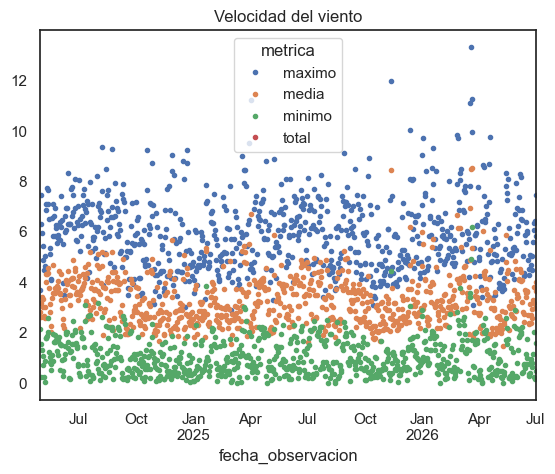

In [73]:
#Pivoteamos la tabla
df_wsp_plot = df_wsp.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
df_wsp_plot.plot(style=".", title="Velocidad del viento")

<Axes: title={'center': 'Temperatura'}, xlabel='fecha_observacion'>

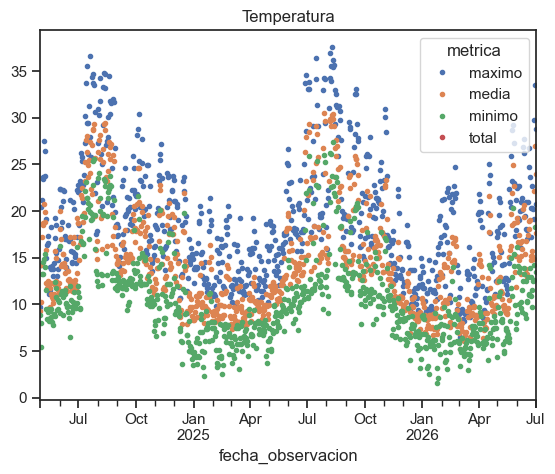

In [74]:
sns.set_style("ticks")

#Pivoteamos la tabla
df_temp_plot = df_temp.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
df_temp_plot.plot(style=".", title="Temperatura")

<Axes: title={'center': 'Humedad relativa'}, xlabel='fecha_observacion'>

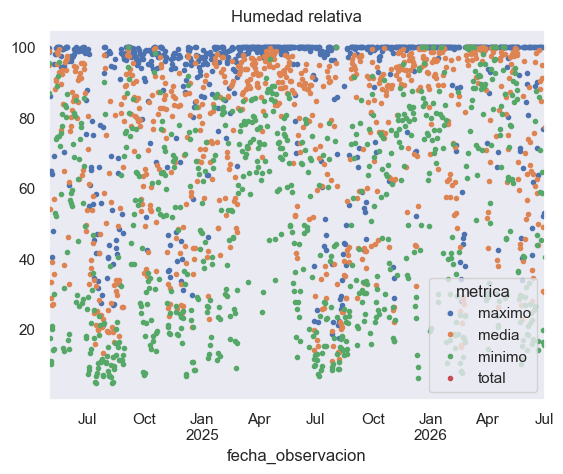

In [75]:
sns.set_style("dark")

#Pivoteamos la tabla
df_hum_plot = df_hum.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
df_hum_plot.plot(style=".", title="Humedad relativa")

<Axes: title={'center': 'Precipitaciones'}, xlabel='fecha_observacion'>

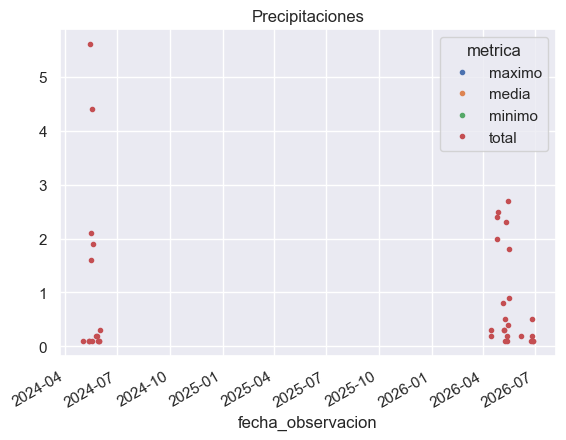

In [76]:
sns.set_style("darkgrid")

#Pivoteamos la tabla
df_rain_plot = df_rain.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
df_rain_plot.plot(style=".",title="Precipitaciones")

<Axes: title={'center': 'Radiación Solar'}, xlabel='fecha_observacion'>

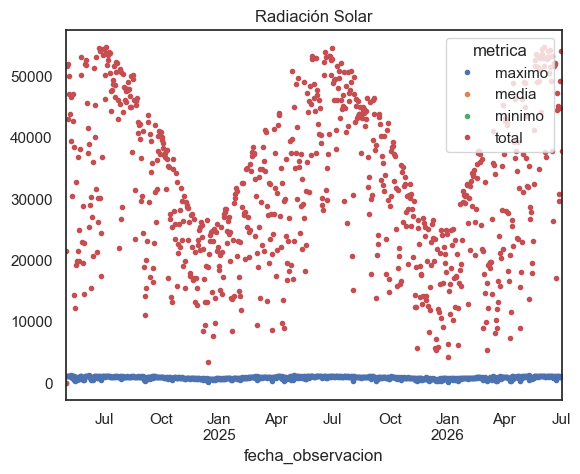

In [77]:
sns.set_theme(style="white")

#Pivoteamos la tabla
df_rad_plot = df_rad.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos

df_rad_plot.plot(style=".", title="Radiación Solar")

# Datos por año:

Volviendo a los dataset anuales, vamos a comparar cada año uno a uno. Para ello volvemos a separar los datos de cada uno por sensor para sacar las métricas y representarlas en distintos set pero en una misma figura combinando lñas librerías de seaborn (gráfico) y matplotlib (estructura conjunta).
* AÑOS
    * 2024
    * 2025
    * 2026

In [ ]:
#2024
df_wsp_24 = df_2024[df_2024['sensor_alias'] == 'WSP']
df_temp_24 = df_2024[df_2024['sensor_alias'] == 'TEMP']
df_hum_24 = df_2024[df_2024['sensor_alias'] == 'HUM']
df_rain_24 = df_2024[df_2024['sensor_alias'] == 'RAIN']
df_rad_24 = df_2024[df_2024['sensor_alias'] == 'RAD']

df_wsp_24.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_temp_24.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_hum_24.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rain_24.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rad_24.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)

#2025
df_wsp_25 = df_2025[df_2025['sensor_alias'] == 'WSP']
df_temp_25 = df_2025[df_2025['sensor_alias'] == 'TEMP']
df_hum_25 = df_2025[df_2025['sensor_alias'] == 'HUM']
df_rain_25 = df_2025[df_2025['sensor_alias'] == 'RAIN']
df_rad_25 = df_2025[df_2025['sensor_alias'] == 'RAD']

df_wsp_25.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_temp_25.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_hum_25.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rain_25.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rad_25.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)

#2026
df_wsp_26 = df_2026[df_2026['sensor_alias'] == 'WSP']
df_temp_26 = df_2026[df_2026['sensor_alias'] == 'TEMP']
df_hum_26 = df_2026[df_2026['sensor_alias'] == 'HUM']
df_rain_26 = df_2026[df_2026['sensor_alias'] == 'RAIN']
df_rad_26 = df_2026[df_2026['sensor_alias'] == 'RAD']

df_wsp_26.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_temp_26.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_hum_26.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rain_26.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rad_26.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)


#Pivoteamos las tablas mediante un bucle porque son demasiadas para ir una a una como en los casos anteriores
dfs = {
    "wsp": {"2024": df_wsp_24, "2025": df_wsp_25, "2026": df_wsp_26},
    "temp": {"2024": df_temp_24, "2025": df_temp_25, "2026": df_temp_26},
    "hum": {"2024": df_hum_24, "2025": df_hum_25, "2026": df_hum_26},
    "rain": {"2024": df_rain_24, "2026": df_rain_26},
    "rad": {"2024": df_rad_24, "2025": df_rad_25, "2026": df_rad_26},
}

dfs_plot = {}

for sensor in dfs:
    dfs_plot[sensor] = {}
    for year in dfs[sensor]:
        dfs_plot[sensor][year] = dfs[sensor][year].pivot(
            index="fecha_observacion",
            columns="metrica",
            values="valor"
        )

## Velocidad del viento

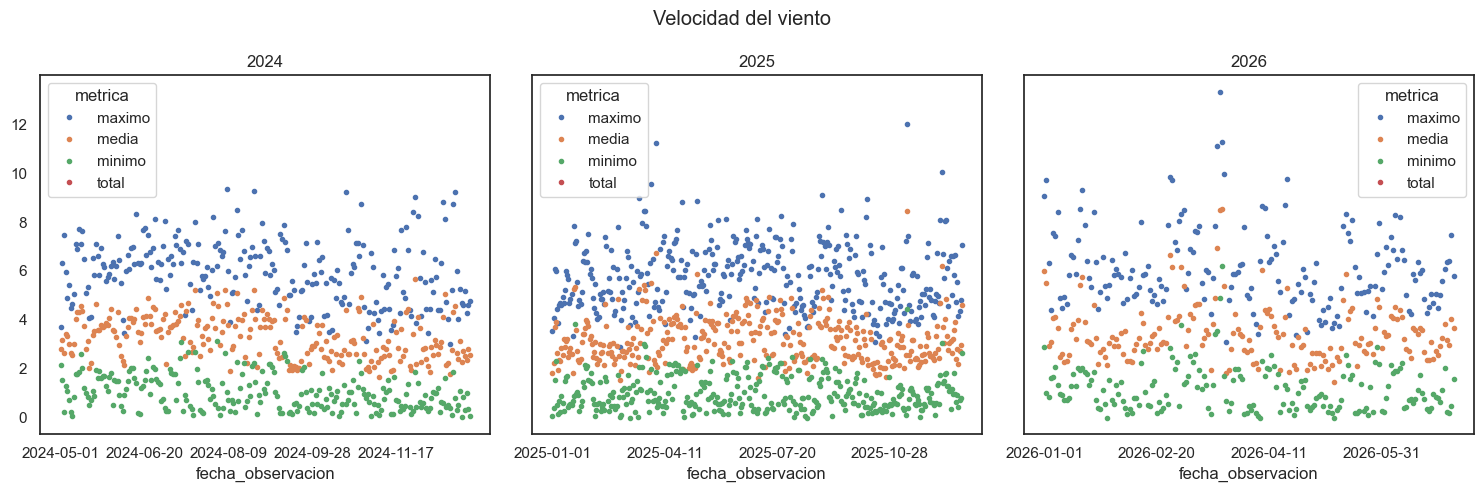

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Velocidad del viento")

#Hacemos los gráficos en bucle para que nos acepte el formato
for ax, year in zip(axes, ["2024", "2025", "2026"]):
    dfs_plot["wsp"][year].plot(
        ax=ax,
        style=".",
        title=year,
        legend=True
    )

plt.tight_layout()
plt.show()

## Temperatura

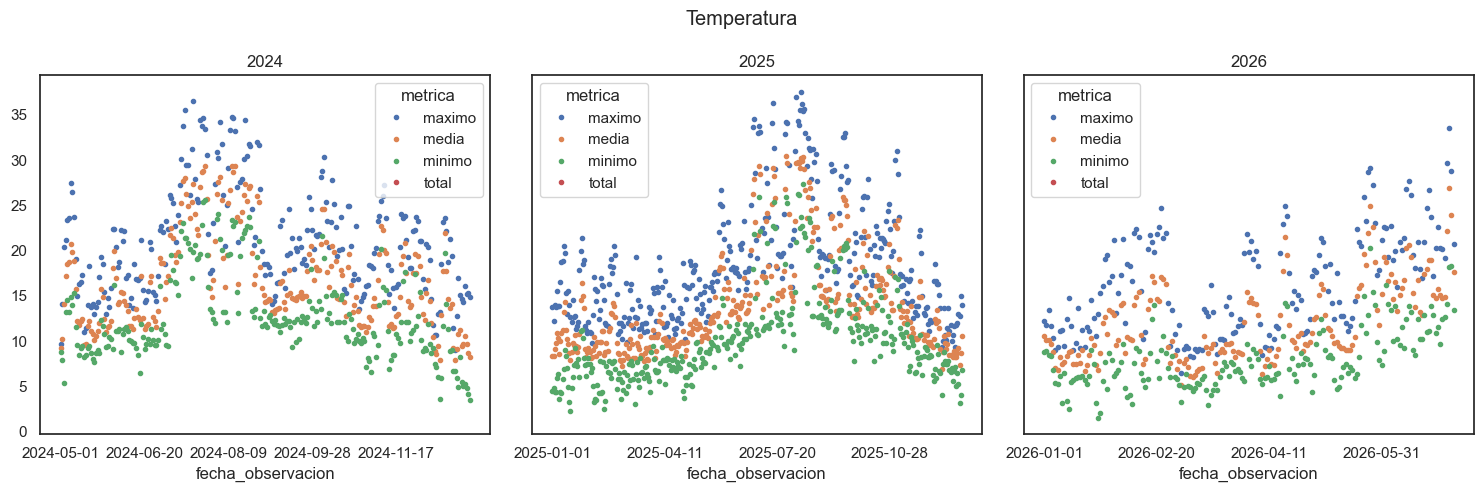

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Temperatura")

for ax, year in zip(axes, ["2024", "2025", "2026"]):
    dfs_plot["temp"][year].plot(
        ax=ax,
        style=".",
        title=year,
        legend=True
    )

plt.tight_layout()
plt.show()

## Humedad relativa

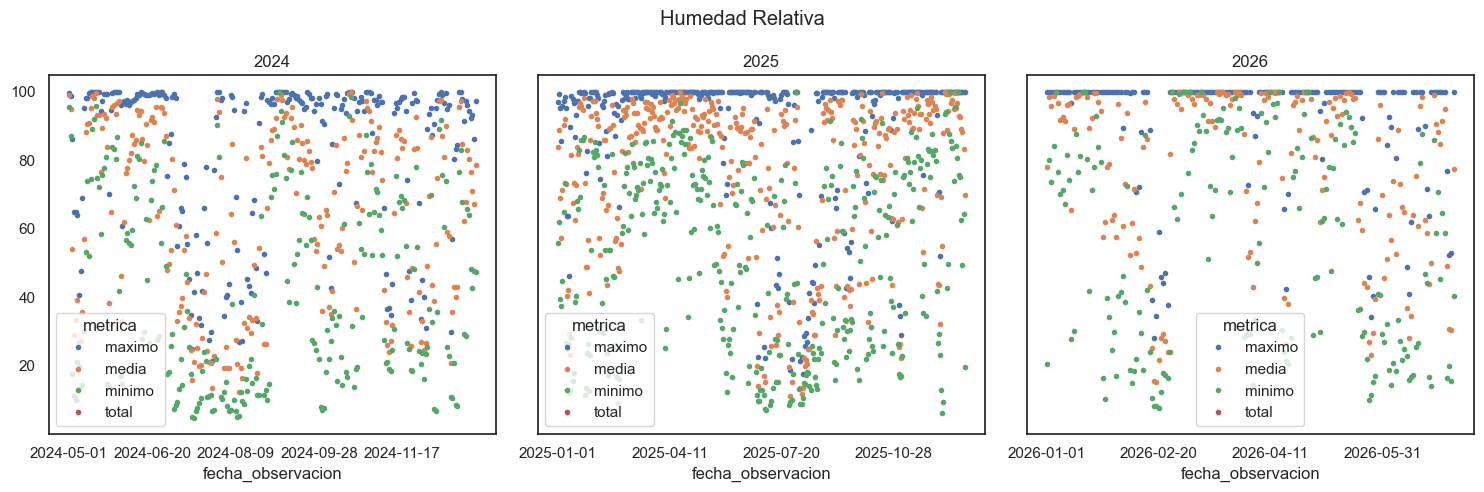

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Humedad Relativa')

for ax, year in zip(axes, ["2024", "2025", "2026"]):
    dfs_plot["hum"][year].plot(
        ax=ax,
        style=".",
        title=year,
        legend=True
    )

plt.tight_layout()
plt.show()

## Precipitaciones

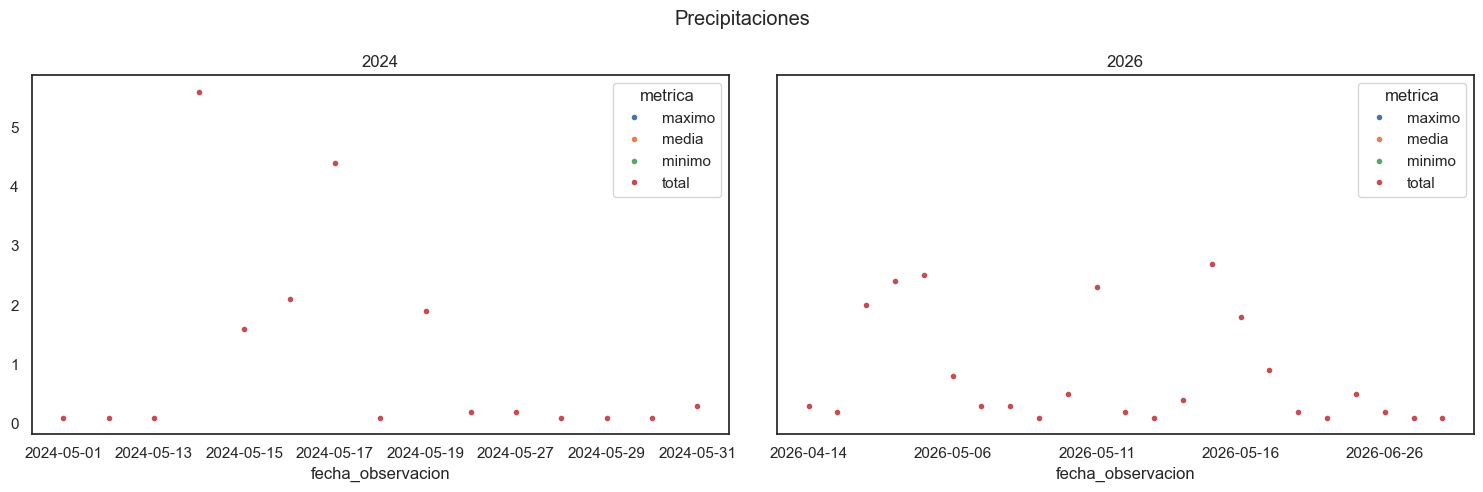

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('Precipitaciones')

for ax, year in zip(axes, ["2024", "2026"]):
    dfs_plot["rain"][year].plot(
        ax=ax,
        style=".",
        title=year,
        legend=True
    )

plt.tight_layout()
plt.show()

## Radiación solar

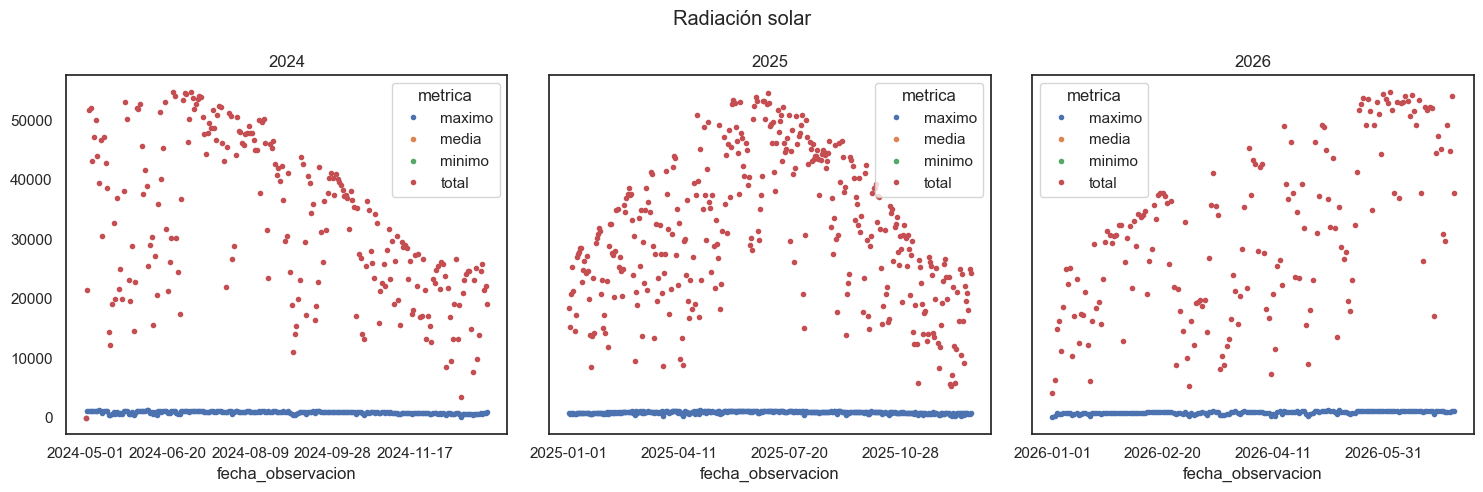

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Radiación solar')


for ax, year in zip(axes, ["2024", "2025", "2026"]):
    dfs_plot["rad"][year].plot(
        ax=ax,
        style=".",
        title=year,
        legend=True
    )

plt.tight_layout()
plt.show()